# SO-NARX Training Pipeline

**Single-Step-Ahead NARX** the model takes a window of past measurements and control inputs to AE (3796->25)
(`narx_state_features`, shape nx**3796**) and predicts the **full output vector at k+1**
(`labels`, shape nx**26*: 9 reactor temperatures, 8 thermostat temperatures,
8 heating-power averages, 1 T_reactor_max).

`heating_power_avg` and `integral_term` are **predicted outputs only** — they are not fed back
as autoregressive inputs. The feature window contains `T_reactor_meas` (9 dims) and
`T_thermostat_meas` (8 dims) as state history, plus `flow_inlet` + `T_setpoint_thermostats`
as control history (**146 lags × 15 s/step ≈ residence time**, V=9.12 L, Q=4.17 µL/s).

Split: **70 % train / 10 % val / 20 % test — simulation-wise** (full trajectories stay intact; no
timestep from a test simulation appears in training).

Architecture: feed-forward MLP trained with PyTorch Lightning on GPU.

In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

torch.set_float32_matmul_precision('high')

sys.path.insert(0, os.path.abspath('.'))

from helpers.helper_classes import MLP, GeLU, NARX_AE
from helpers.helpers import (
    load_narx_dataset_with_metadata,
    load_scaler_params,
    scale_data,
    scale_data_with_scaler,
    unscale_data,
    get_simulation_split_dataloaders,
    get_standard_trainer,
    save_model_metadata,
    evaluate_on_test_set,
    recursive_narx_rollout,
    visualize_training_logs,
    get_latest_version_dir,
    create_next_version_dir,
    filter_narx_data_by_vars,
)

print(f'PyTorch  : {torch.__version__}')
print(f'Lightning: {pl.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

W0530 16:23:10.485000 4580 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


PyTorch  : 2.11.0+cu128
Lightning: 2.6.1
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Configuration
DATASET_PATH  = '../../Data_Sampling/datasets/21_05_2026/narx/thermal_narx_dataset_3.h5'
RAW_HDF5      = '../../Data_Sampling/datasets/21_05_2026/thermal_cobr_raw_data.h5'

# Toggle: True  → 26-output model (T_reactor×9, T_thermostat×8, heating_power_avg×8, 1x T_reactor_max)
#         False → 17-output model (T_reactor×9, T_thermostat×8 only)
INCLUDE_HP_INT = True

# Feature window layout — must match the dataset config.
# State groups in feature window (heating_power_avg & integral_term are NOT included).
STATE_GROUP_DIMS = [9, 8]   # T_reactor_meas (9 positions), T_thermostat_meas (8 zones)
N_CTRL_DIMS      = 9        # flow_inlet (1) + T_setpoint_thermostats (8)

_hp_suffix = '' if INCLUDE_HP_INT else '_noHPINT'
LOG_DIR    = f'logs/SO_NARX{_hp_suffix}'
EXPERIMENT = f'SO_NARX{_hp_suffix}'

LATENT_DIM    = 25
ALPHA        = 0.3
BETA        = 1.0
HIDDEN_DIMS   = [512, 256, 128]
LEARNING_RATE = 1e-3
MAX_EPOCHS    = 500
BATCH_SIZE    = 8192

TRAIN_FRAC = 0.7   # fraction of simulations used for training
VAL_FRAC   = 0.1   # fraction used for validation (scheduler / early stopping)
TEST_FRAC  = 0.2   # remaining simulations held out as test set
SPLIT_SEED = 42    # reproducible simulation shuffle

network_hyperparameters = {
    'input_dim': ...,
    'encoder_dims': [512, 256],
    'latent_dim': LATENT_DIM,
    'decoder_dims': [256, 512],
    'pred_head_dims': [64],
    'output_dim': ...,
    'activation': GeLU(),
    'noise_sigma': 0.05,
}

training_hyperparameters = {
    'loss_function': nn.MSELoss(),
    'optimizer_class': torch.optim.Adam,
    'optimizer_kwargs': {'lr': LEARNING_RATE},
    'scheduler_class': torch.optim.lr_scheduler.ReduceLROnPlateau,
    'scheduler_kwargs': {'factor': 0.5, 'patience': 10},
    'alpha': ALPHA,
    'beta': BETA,
}

# Set True ONLY to resume an interrupted run from last.ckpt in the latest version dir.
RESUME = False

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
ACCELERATOR = 'gpu'  if DEVICE == 'cuda'           else 'cpu'

os.makedirs(LOG_DIR, exist_ok=True)
print(f'Device        : {DEVICE}')
print(f'INCLUDE_HP_INT: {INCLUDE_HP_INT}  →  {26 if INCLUDE_HP_INT else 17} outputs')
print(f'Feature layout: state_group_dims={STATE_GROUP_DIMS}, n_ctrl_dims={N_CTRL_DIMS}')
print(f'Logs          : {os.path.abspath(LOG_DIR)}')
print(f'Resume        : {RESUME}')

Device        : cuda
INCLUDE_HP_INT: True  →  26 outputs
Feature layout: state_group_dims=[9, 8], n_ctrl_dims=9
Logs          : c:\Users\Harshit\Documents\TU DO\Thesis\Run_1\logs\SO_NARX
Resume        : False


In [3]:
# Load dataset
data, metadata = load_narx_dataset_with_metadata(DATASET_PATH)

print('Data arrays:')
for k, v in data.items():
    print(f'  {k}: {tuple(v.shape)}')

# Build label name list from metadata
label_names = []
if 'labels' in metadata:
    for var_meta in metadata['labels']:
        name = var_meta['name']
        n_dims = var_meta.get('selected_dims', 1)
        if n_dims > 1:
            label_names.extend([f'{name}[{i}]' for i in range(n_dims)])
        else:
            label_names.append(name)

print(f'\nLabel columns ({len(label_names)}):')
for i, name in enumerate(label_names):
    print(f'  [{i}] {name}')


Data arrays:
  input_features: (1124247, 9)
  labels: (1124247, 26)
  narx_state_features: (1124247, 3796)
  sim_sample_counts: (499,)

Label columns (26):
  [0] T_reactor_meas[0]
  [1] T_reactor_meas[1]
  [2] T_reactor_meas[2]
  [3] T_reactor_meas[3]
  [4] T_reactor_meas[4]
  [5] T_reactor_meas[5]
  [6] T_reactor_meas[6]
  [7] T_reactor_meas[7]
  [8] T_reactor_meas[8]
  [9] T_thermostat_meas[0]
  [10] T_thermostat_meas[1]
  [11] T_thermostat_meas[2]
  [12] T_thermostat_meas[3]
  [13] T_thermostat_meas[4]
  [14] T_thermostat_meas[5]
  [15] T_thermostat_meas[6]
  [16] T_thermostat_meas[7]
  [17] heating_power_avg[0]
  [18] heating_power_avg[1]
  [19] heating_power_avg[2]
  [20] heating_power_avg[3]
  [21] heating_power_avg[4]
  [22] heating_power_avg[5]
  [23] heating_power_avg[6]
  [24] heating_power_avg[7]
  [25] T_reactor


In [4]:
# Scale features and labels (cast to float32 for GPU)
features_t = data['narx_state_features'].float()
labels_t   = data['labels'].float()

# Apply INCLUDE_HP_INT filter — drops heating_power_avg & integral_term when False
_EXCLUDE = [] if INCLUDE_HP_INT else ['heating_power_avg']
features_t, labels_t, label_names, active_metadata = filter_narx_data_by_vars(
    features_t, labels_t, metadata, exclude_var_names=_EXCLUDE,
)
print(f'Feature dim: {features_t.shape[1]}   Label dim: {labels_t.shape[1]}')
print(f'Labels ({len(label_names)}): {label_names}')

features_np = features_t.numpy()
labels_np   = labels_t.numpy()

feat_scaler_path  = os.path.join(LOG_DIR, 'feature_scaler.yml')
label_scaler_path = os.path.join(LOG_DIR, 'label_scaler.yml')

features_scaled, feat_scaler  = scale_data(features_np, _torch=True, dtype=torch.float32,
                                            save_path=feat_scaler_path)
labels_scaled,   label_scaler = scale_data(labels_np,   _torch=True, dtype=torch.float32,
                                            save_path=label_scaler_path)

print(f'Features: {tuple(features_scaled.shape)}  dtype={features_scaled.dtype}')
print(f'Labels  : {tuple(labels_scaled.shape)}   dtype={labels_scaled.dtype}')
print(f'Scaler files saved to {LOG_DIR}/')

Feature dim: 3796   Label dim: 26
Labels (26): ['T_reactor_meas[0]', 'T_reactor_meas[1]', 'T_reactor_meas[2]', 'T_reactor_meas[3]', 'T_reactor_meas[4]', 'T_reactor_meas[5]', 'T_reactor_meas[6]', 'T_reactor_meas[7]', 'T_reactor_meas[8]', 'T_thermostat_meas[0]', 'T_thermostat_meas[1]', 'T_thermostat_meas[2]', 'T_thermostat_meas[3]', 'T_thermostat_meas[4]', 'T_thermostat_meas[5]', 'T_thermostat_meas[6]', 'T_thermostat_meas[7]', 'heating_power_avg[0]', 'heating_power_avg[1]', 'heating_power_avg[2]', 'heating_power_avg[3]', 'heating_power_avg[4]', 'heating_power_avg[5]', 'heating_power_avg[6]', 'heating_power_avg[7]', 'T_reactor[0]']
Features: (1124247, 3796)  dtype=torch.float32
Labels  : (1124247, 26)   dtype=torch.float32
Scaler files saved to logs/SO_NARX/


In [5]:
import h5py

_MAX_N_PAST = max(
    (v.get('n_past', 0)
     for g in metadata.get('feature_groups', {}).values()
     for v in g),
    default=0,
)
_MAX_DELAY = max(
    (v.get('delay', 0)
     for g in metadata.get('feature_groups', {}).values()
     for v in g),
    default=0,
)

with h5py.File(DATASET_PATH, 'r') as _f:
    sim_sample_counts = np.array(_f['sim_sample_counts'], dtype=np.int64)

print(f'max_n_past={_MAX_N_PAST}, max_delay={_MAX_DELAY}')
print(f'Simulations      : {len(sim_sample_counts)}')
print(f'Samples per sim  : min={sim_sample_counts.min()}, max={sim_sample_counts.max()}, '
      f'mean={sim_sample_counts.mean():.0f}')
print(f'Total (check)    : {sim_sample_counts.sum():,}  (dataset has {features_scaled.shape[0]:,})')

train_loader, val_loader, test_loader = get_simulation_split_dataloaders(
    features_scaled, labels_scaled,
    sim_sample_counts=sim_sample_counts,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    batch_size=BATCH_SIZE,
    seed=SPLIT_SEED,
    multiprocessing=False,
)

max_n_past=146, max_delay=1
Simulations      : 499
Samples per sim  : min=2253, max=2253, mean=2253
Total (check)    : 1,124,247  (dataset has 1,124,247)
Simulation split (seed=42): 349 train sims (786,297 samples) | 49 val sims (110,397 samples) | 101 test sims (227,553 samples)


In [6]:
# Build MLP with autoencoder latent space and prediction head.

network_hyperparameters['input_dim'] = features_scaled.shape[1]
network_hyperparameters['output_dim'] = labels_scaled.shape[1]

model = NARX_AE(network_hyperparameters, training_hyperparameters)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')


NARX_AE(
  (loss_function): MSELoss()
  (encoder): Sequential(
    (0): Linear(in_features=3796, out_features=512, bias=True)
    (1): GeLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): GeLU()
    (4): Linear(in_features=256, out_features=25, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=25, out_features=256, bias=True)
    (1): GeLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): GeLU()
    (4): Linear(in_features=512, out_features=3796, bias=True)
  )
  (pred_head): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): GeLU()
    (2): Linear(in_features=64, out_features=26, bias=True)
  )
)

Trainable parameters: 4,170,759


In [7]:
# Train  -  run this cell when ready
logger = TensorBoardLogger(save_dir=LOG_DIR, name=EXPERIMENT)

ckpt_path = None
if RESUME:
    experiment_dir = os.path.join(LOG_DIR, EXPERIMENT)
    if os.path.isdir(experiment_dir):
        try:
            version_dir = get_latest_version_dir(experiment_dir)
            last_ckpt   = os.path.join(version_dir, 'checkpoints', 'last.ckpt')
            if os.path.exists(last_ckpt):
                ckpt_path = last_ckpt
                print(f'Resuming from: {ckpt_path}')
            else:
                print('RESUME=True but no last.ckpt found — starting fresh')
        except Exception:
            print('No prior version found — starting fresh')
else:
    print('RESUME=False — starting clean run')

trainer = get_standard_trainer(
    logger=logger,
    max_epochs=MAX_EPOCHS,
    accelerator=ACCELERATOR,
)

trainer.fit(model, train_loader, val_loader, ckpt_path=ckpt_path)

RESUME=False — starting clean run


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Harshit\Documents\TU DO\Thesis\.venv\Lib\site-packages\lightning_fabric\loggers\csv_logs.py:268: Experiment logs directory logs/SO_NARX\SO_NARX\version_12 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type       | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | loss_function | MSELoss    | 0      | train | 0    
1 | encoder       | Sequential | 2.1 M  | train | 0    
2 | decoder       | Sequential | 2.1 M  | train | 0    
3 | pred_head     | Sequential | 3.4 K  | train | 0    
----------------------------------

Epoch 217: 100%|██████████| 96/96 [00:22<00:00,  4.22it/s, v_num=12, train_loss=0.004, val_loss=0.00775]  


In [8]:
# Export full self-contained model and create versioned save directory
MODELS_BASE = 'Models'
MODEL_SAVE_DIR = create_next_version_dir(MODELS_BASE)

pt_path = os.path.join(MODEL_SAVE_DIR, 'narx_model_full.pt')
torch.save(model, pt_path)
print(f'Model saved to: {pt_path}')

# Copy scalers into the versioned model dir so each version is self-contained
import shutil
for scaler_name in ('feature_scaler.yml', 'label_scaler.yml'):
    src = os.path.join(LOG_DIR, scaler_name)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(MODEL_SAVE_DIR, scaler_name))
        print(f'Copied {scaler_name} → {MODEL_SAVE_DIR}/')

print(f'Save directory: {os.path.abspath(MODEL_SAVE_DIR)}')


Model saved to: Models\version_12\narx_model_full.pt
Copied feature_scaler.yml → Models\version_12/
Copied label_scaler.yml → Models\version_12/
Save directory: c:\Users\Harshit\Documents\TU DO\Thesis\Run_1\Models\version_12


In [9]:
# Save model metadata
model_config = {
    'network_hyperparameters': {
        'input_dim':   network_hyperparameters['input_dim'],
        'encoder_dims': network_hyperparameters['encoder_dims'],
        'latent_dim':  network_hyperparameters['latent_dim'],
        'decoder_dims': network_hyperparameters['decoder_dims'],
        'pred_head_dims': network_hyperparameters['pred_head_dims'],
        'output_dim':  network_hyperparameters['output_dim'],
        'activation':  type(network_hyperparameters['activation']).__name__,
    },
    'training_hyperparameters': {
        'loss_function': type(training_hyperparameters['loss_function']).__name__,
        'optimizer':     training_hyperparameters['optimizer_class'].__name__,
        'learning_rate': LEARNING_RATE,
        'batch_size':    BATCH_SIZE,
        'max_epochs':    MAX_EPOCHS,
        'scheduler':     training_hyperparameters['scheduler_class'].__name__,
        'alpha': ALPHA,
        'beta': BETA,
    },
    'data_split': {
        'method': 'simulation-wise',
        'train':  TRAIN_FRAC,
        'val':    VAL_FRAC,
        'test':   TEST_FRAC,
        'seed':   SPLIT_SEED,
    },
    'include_hp_int': INCLUDE_HP_INT,
    'label_names':    label_names,
}

version_dir = get_latest_version_dir(os.path.join(LOG_DIR, EXPERIMENT))
save_model_metadata(version_dir, active_metadata, model_config, DATASET_PATH)
print(f'Metadata saved to: {version_dir}')

# Copy metadata to Models dir so each version is self-contained for comparison
shutil.copy2(os.path.join(version_dir, 'model_metadata.yml'),
             os.path.join(MODEL_SAVE_DIR, 'model_metadata.yml'))
print(f'Copied model_metadata.yml → {MODEL_SAVE_DIR}/')
if os.path.exists(os.path.join(version_dir, 'metrics.csv')):
    shutil.copy2(os.path.join(version_dir, 'metrics.csv'),
                 os.path.join(MODEL_SAVE_DIR, 'metrics.csv'))
    print(f'Copied metrics.csv → {MODEL_SAVE_DIR}/')

Saved model metadata to: logs/SO_NARX\SO_NARX\version_12\model_metadata.yml
Metadata saved to: logs/SO_NARX\SO_NARX\version_12
Copied model_metadata.yml → Models\version_12/
Copied metrics.csv → Models\version_12/


In [10]:
# Evaluate on test set
results = evaluate_on_test_set(model, test_loader, label_scaler, device=DEVICE)

header = f"{'Output':<30} {'RMSE':>8} {'MAE':>8} {'R2':>8}"
print(header)
print('-' * 58)
for i, name in enumerate(label_names):
    rmse = results['rmse'][i]
    mae  = results['mae'][i]
    r2   = results['r2'][i]
    print(f'{name:<30} {rmse:8.4f} {mae:8.4f} {r2:8.4f}')
print('-' * 58)
print(f"Mean RMSE: {results['mean_rmse']:.4f}")


Output                             RMSE      MAE       R2
----------------------------------------------------------
T_reactor_meas[0]                0.2070   0.1639   0.9989
T_reactor_meas[1]                0.2738   0.2157   0.9987
T_reactor_meas[2]                0.2411   0.1912   0.9988
T_reactor_meas[3]                0.2303   0.1815   0.9988
T_reactor_meas[4]                0.2275   0.1783   0.9990
T_reactor_meas[5]                0.1994   0.1560   0.9992
T_reactor_meas[6]                0.1943   0.1493   0.9992
T_reactor_meas[7]                0.1985   0.1552   0.9990
T_reactor_meas[8]                0.2087   0.1659   0.9991
T_thermostat_meas[0]             0.5374   0.3887   0.9979
T_thermostat_meas[1]             0.5494   0.4002   0.9983
T_thermostat_meas[2]             0.5445   0.3953   0.9976
T_thermostat_meas[3]             0.5556   0.4060   0.9976
T_thermostat_meas[4]             0.5558   0.4056   0.9980
T_thermostat_meas[5]             0.5561   0.4059   0.9980
T_thermostat_

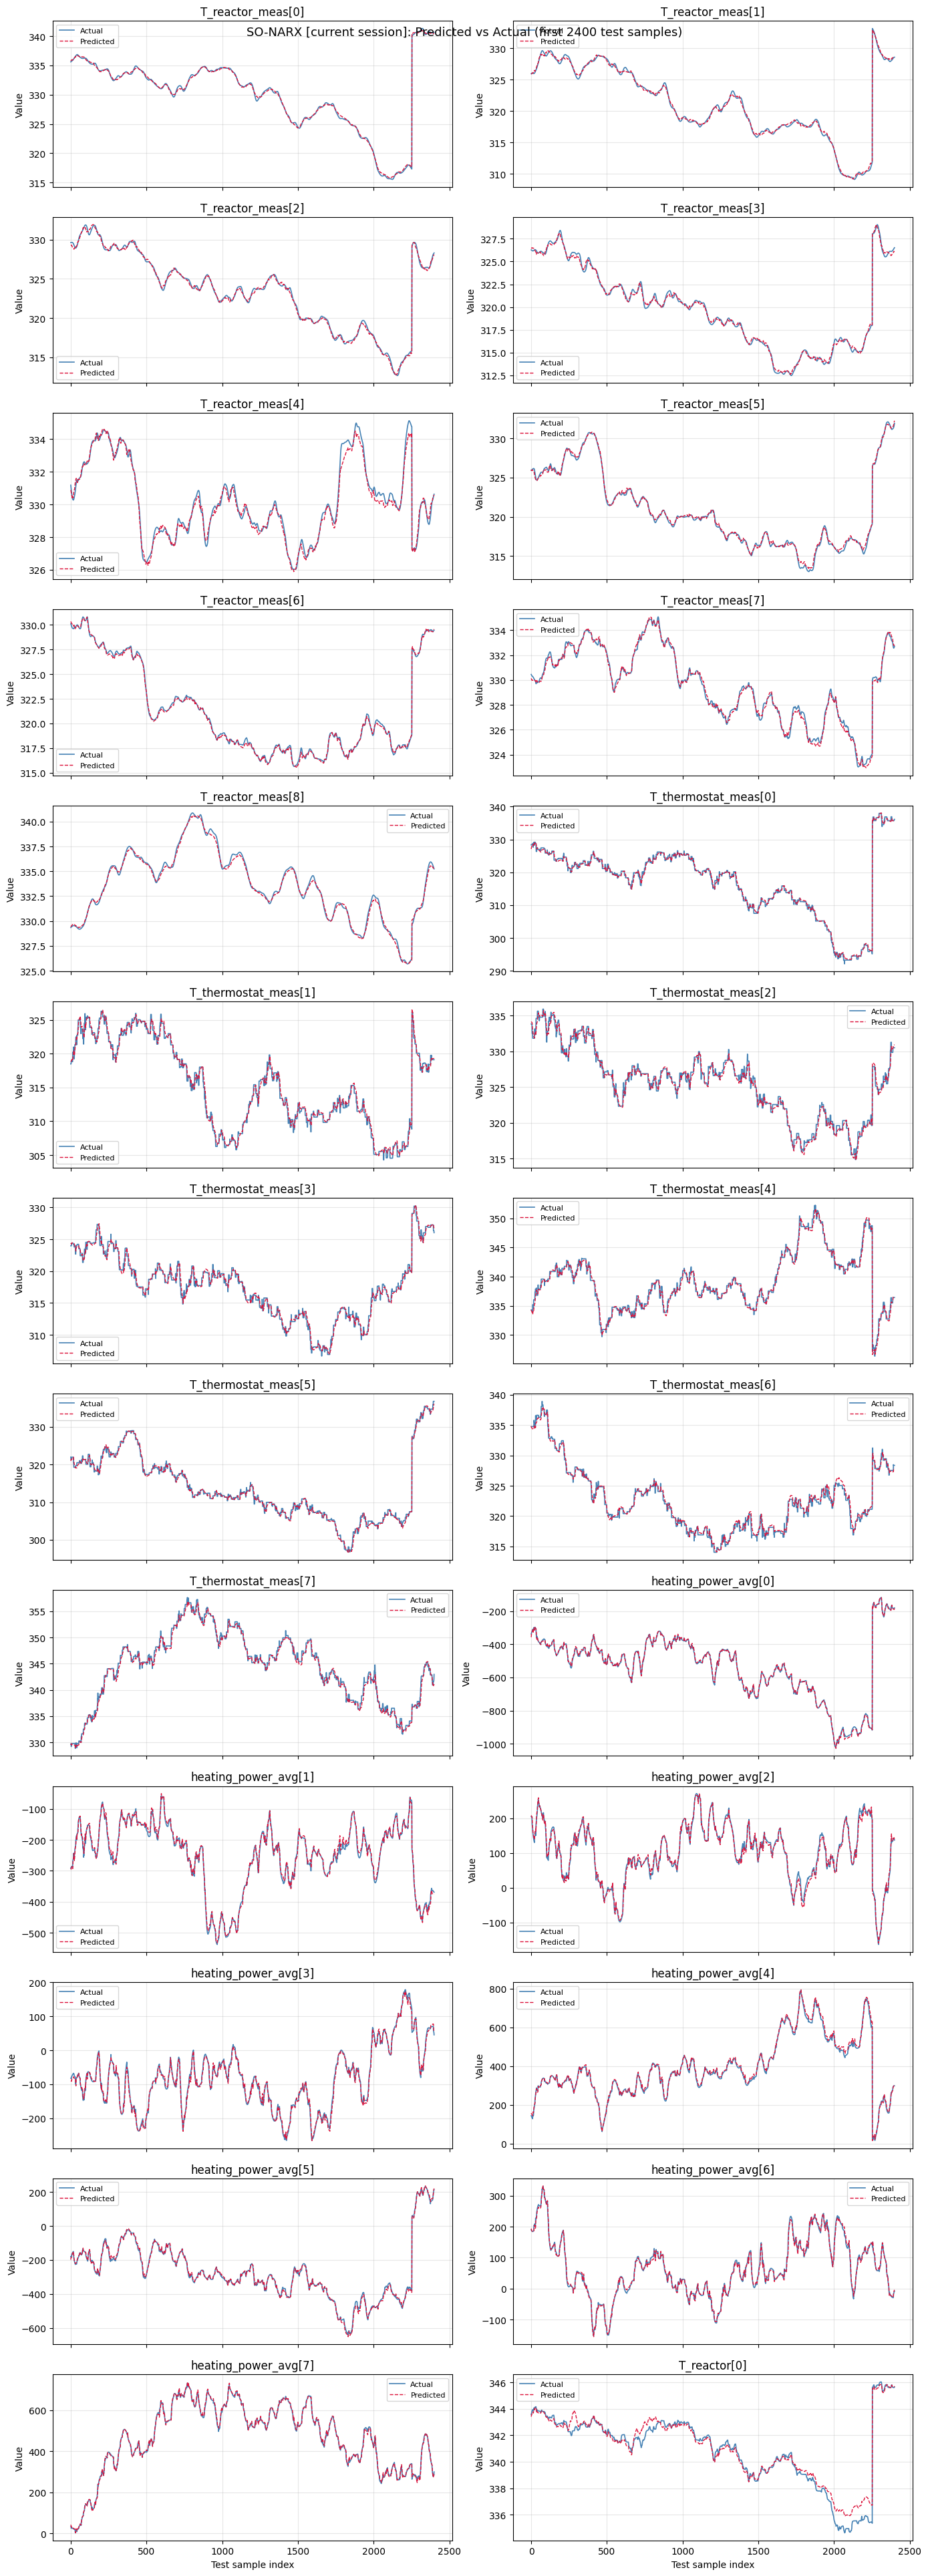

In [11]:
import yaml

# ── CONFIG: None = current session | 'version_9' = reload from Models/ ────────
EVAL_VERSION = None

if EVAL_VERSION is None:
    _eval_results = results
    _eval_labels  = label_names
    _eval_savedir = MODEL_SAVE_DIR
else:
    _eval_dir = os.path.join('Models', EVAL_VERSION)
    with open(os.path.join(_eval_dir, 'model_metadata.yml')) as _mf:
        _emeta = yaml.safe_load(_mf)

    _eval_labels = _emeta['model_config']['label_names']
    _ds_path     = _emeta['dataset_path']
    _inc_hp      = _emeta['model_config'].get('include_hp_int', True)
    _split       = _emeta['model_config']['data_split']
    _val_frac    = _split.get('val', 1.0 - _split.get('train', 0.7) - _split.get('test', 0.2))
    print(f'Re-evaluating {EVAL_VERSION}: {len(_eval_labels)} outputs')
    print(f'Dataset: {_ds_path}')

    # Load the dataset this model was trained on
    _edata, _edmeta = load_narx_dataset_with_metadata(_ds_path)
    _eft = _edata['narx_state_features'].float()
    _elb = _edata['labels'].float()
    _excl = [] if _inc_hp else ['heating_power_avg']
    _eft, _elb, _, _ = filter_narx_data_by_vars(_eft, _elb, _edmeta, exclude_var_names=_excl)

    # Scale with this model's own scalers (not the current session's)
    _efsc = load_scaler_params(os.path.join(_eval_dir, 'feature_scaler.yml'))
    _elsc = load_scaler_params(os.path.join(_eval_dir, 'label_scaler.yml'))
    _eft_sc = scale_data_with_scaler(_eft, _efsc, _torch=True)
    _elb_sc = scale_data_with_scaler(_elb, _elsc, _torch=True)

    # Reconstruct the exact test split used at training time
    _esim_counts = _edata.get('sim_sample_counts')
    if _esim_counts is not None:
        _, _, _etest_loader = get_simulation_split_dataloaders(
            _eft_sc, _elb_sc, _esim_counts,
            train_frac=_split.get('train', 0.7),
            val_frac=_val_frac,
            batch_size=BATCH_SIZE,
            seed=_split.get('seed', 42),
            multiprocessing=False,
        )
    else:
        _tn = int(0.8 * _eft_sc.shape[0])
        from torch.utils.data import TensorDataset, DataLoader as _DL
        _etest_loader = _DL(TensorDataset(_eft_sc[_tn:], _elb_sc[_tn:]),
                            batch_size=BATCH_SIZE, shuffle=False)

    _emodel = torch.load(os.path.join(_eval_dir, 'narx_model_full.pt'),
                         map_location=DEVICE, weights_only=False)
    _eval_results = evaluate_on_test_set(_emodel, _etest_loader, _elsc, device=DEVICE)
    _eval_savedir = _eval_dir

# ── Plot ───────────────────────────────────────────────────────────────────────
preds   = _eval_results['predictions']
targets = _eval_results['targets']
n_plot  = min(2400, preds.shape[0])
t_axis  = np.arange(n_plot)

n_out  = preds.shape[1]
n_cols = 2
n_rows = (n_out + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i in range(n_out):
    ax = axes[i]
    ax.plot(t_axis, targets[:n_plot, i], label='Actual',    color='steelblue', linewidth=1.2)
    ax.plot(t_axis, preds[:n_plot, i],   label='Predicted', color='crimson',   linewidth=1.0, linestyle='--')
    ax.set_title(_eval_labels[i] if i < len(_eval_labels) else f'Output {i}')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[n_out:]:
    ax.set_visible(False)
for ax in axes[max(0, n_out - n_cols):n_out]:
    ax.set_xlabel('Test sample index')

_ver_tag = EVAL_VERSION or ('current session' if EVAL_VERSION is None else EVAL_VERSION)
fig.suptitle(f'SO-NARX [{_ver_tag}]: Predicted vs Actual (first {n_plot} test samples)', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(_eval_savedir, 'test_predictions.png'), dpi=150)
plt.show()


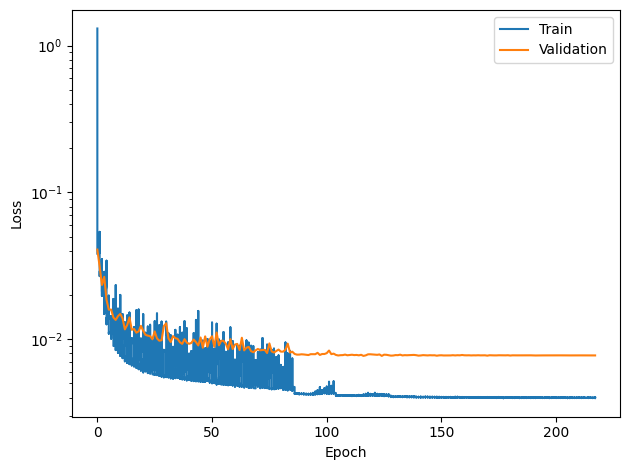

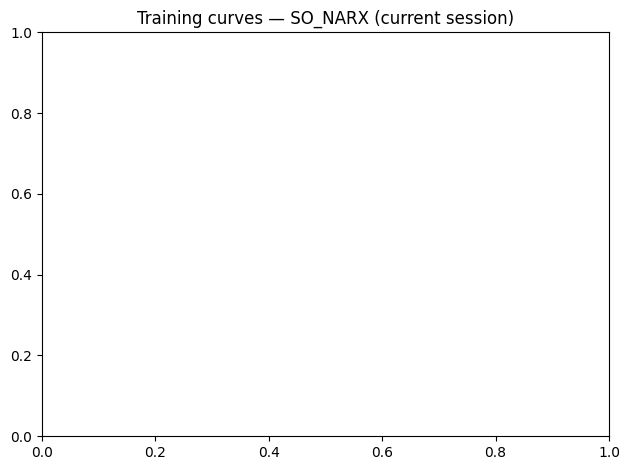

In [12]:
import yaml

# ── CONFIG: None = current session | 'version_9' = load metrics from Models/ ─
EVAL_VERSION = None

if EVAL_VERSION is None:
    _ver_dir    = get_latest_version_dir(os.path.join(LOG_DIR, EXPERIMENT))
    _metrics    = os.path.join(_ver_dir, 'metrics.csv')
    _title      = f'Training curves — {EXPERIMENT} (current session)'
else:
    _ver_dir  = os.path.join('Models', EVAL_VERSION)
    _metrics  = os.path.join(_ver_dir, 'metrics.csv')
    _title    = f'Training curves — {EVAL_VERSION}'

if not os.path.exists(_metrics):
    print(f'metrics.csv not found at: {_metrics}')
    if EVAL_VERSION is not None:
        print('Tip: re-run cell 9 after training to copy metrics.csv into the Models directory.')
else:
    visualize_training_logs(_ver_dir)
    plt.title(_title)
    plt.tight_layout()
    plt.show()


Loaded model from: c:\Users\Harshit\Documents\TU DO\Thesis\Run_1\Models\version_12
Test set: 227,553 samples from held-out simulations
Rollout mode: full AR


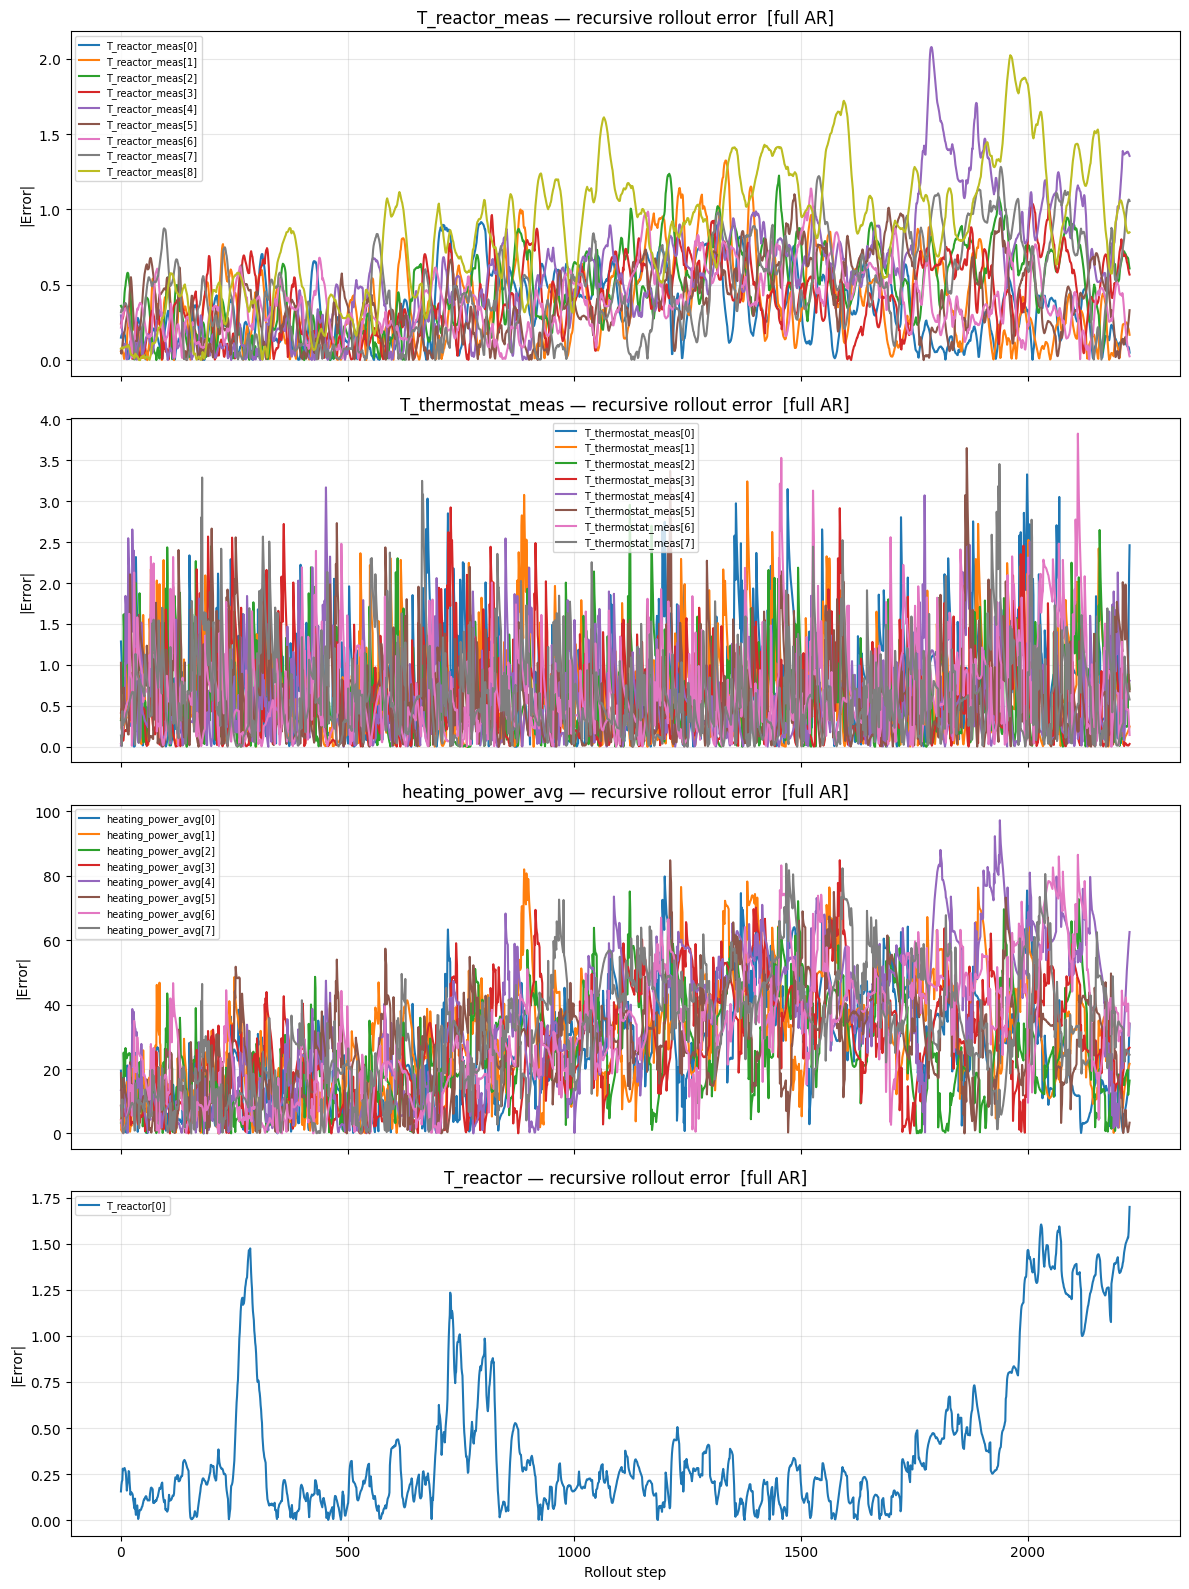

Rollout error plot saved to: Models\version_12\recursive_rollout_error.png


In [14]:
import importlib, helpers.helpers as _hh
importlib.reload(_hh)
from helpers.helpers import recursive_narx_rollout, recursive_narx_rollout_partial
from collections import OrderedDict

# ── CONFIG ─────────────────────────────────────────────────────────────────────
N_ROLLOUT = 2225   # number of recursive steps (1 step = 15 s)
START_IDX = 0

# Feature window layout — must match the trained model's dataset.
# Set None to use backward-compatible inference (DIMS=4, N_CTRL=5) for old models (v5–v8).
_LAYOUT = dict(state_group_dims=STATE_GROUP_DIMS, n_ctrl_dims=N_CTRL_DIMS)

# For new architecture (v9+): heating_power_avg / integral_term are not in the feature
# window, so PARTIAL_AUTOREGRESSIVE has no effect — full AR and partial AR are identical.
# Only meaningful for old models that had all 4 groups as AR inputs.
PARTIAL_AUTOREGRESSIVE = False

# ── Load latest model ──────────────────────────────────────────────────────────
_rollout_model_dir = get_latest_version_dir('Models')
_rollout_model     = torch.load(
    os.path.join(_rollout_model_dir, 'narx_model_full.pt'),
    map_location=DEVICE,
    weights_only=False,
)
_rollout_model.eval()
print(f'Loaded model from: {os.path.abspath(_rollout_model_dir)}')

# Gather test set tensors
_Xb, _yb = zip(*[(xb, yb) for xb, yb in test_loader])
X_test = torch.cat(_Xb)
y_test = torch.cat(_yb)
print(f'Test set: {X_test.shape[0]:,} samples from held-out simulations')

# ── Run rollout ────────────────────────────────────────────────────────────────
_rollout_kwargs = dict(N_rollout=N_ROLLOUT, start_idx=START_IDX, device=DEVICE, **_LAYOUT)

if PARTIAL_AUTOREGRESSIVE:
    _n_ar = len(STATE_GROUP_DIMS) if STATE_GROUP_DIMS else 2
    rollout = recursive_narx_rollout_partial(
        _rollout_model, X_test, y_test,
        feat_scaler, label_scaler,
        n_autoregressive_vars=_n_ar,
        **_rollout_kwargs,
    )
else:
    rollout = recursive_narx_rollout(
        _rollout_model, X_test, y_test,
        feat_scaler, label_scaler,
        **_rollout_kwargs,
    )

_mode_label = 'partial AR' if PARTIAL_AUTOREGRESSIVE else 'full AR'
print(f'Rollout mode: {_mode_label}')

# ── Plot error accumulation — one subplot per output variable group ─────────────
t_steps     = np.arange(N_ROLLOUT)
_n_out      = rollout['abs_error'].shape[1]
_plot_names = label_names if len(label_names) == _n_out else [f'Output {i}' for i in range(_n_out)]

# Group indices by base variable name (strip '[i]' suffix)
_groups = OrderedDict()
for _i, _nm in enumerate(_plot_names):
    _base = _nm.rsplit('[', 1)[0].rstrip('_')
    _groups.setdefault(_base, []).append(_i)

fig, axes = plt.subplots(len(_groups), 1, figsize=(12, 4 * len(_groups)), sharex=True)
if len(_groups) == 1:
    axes = [axes]

for _ax, (_grp_name, _idxs) in zip(axes, _groups.items()):
    for _idx in _idxs:
        _ax.plot(t_steps, rollout['abs_error'][:, _idx], label=_plot_names[_idx])
    _ax.set_ylabel('|Error|')
    _ax.set_title(f'{_grp_name} — recursive rollout error  [{_mode_label}]')
    _ax.legend(fontsize=7)
    _ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Rollout step')
plt.tight_layout()
save_path = os.path.join(_rollout_model_dir, 'recursive_rollout_error.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Rollout error plot saved to: {save_path}')

##### Random Trajectory Check

Models to evaluate (1): ['version_12']
Simulation : 350
Sim length : 2400 steps
  version_12  [metadata]  ... OK  (steps=2254, outputs=26)


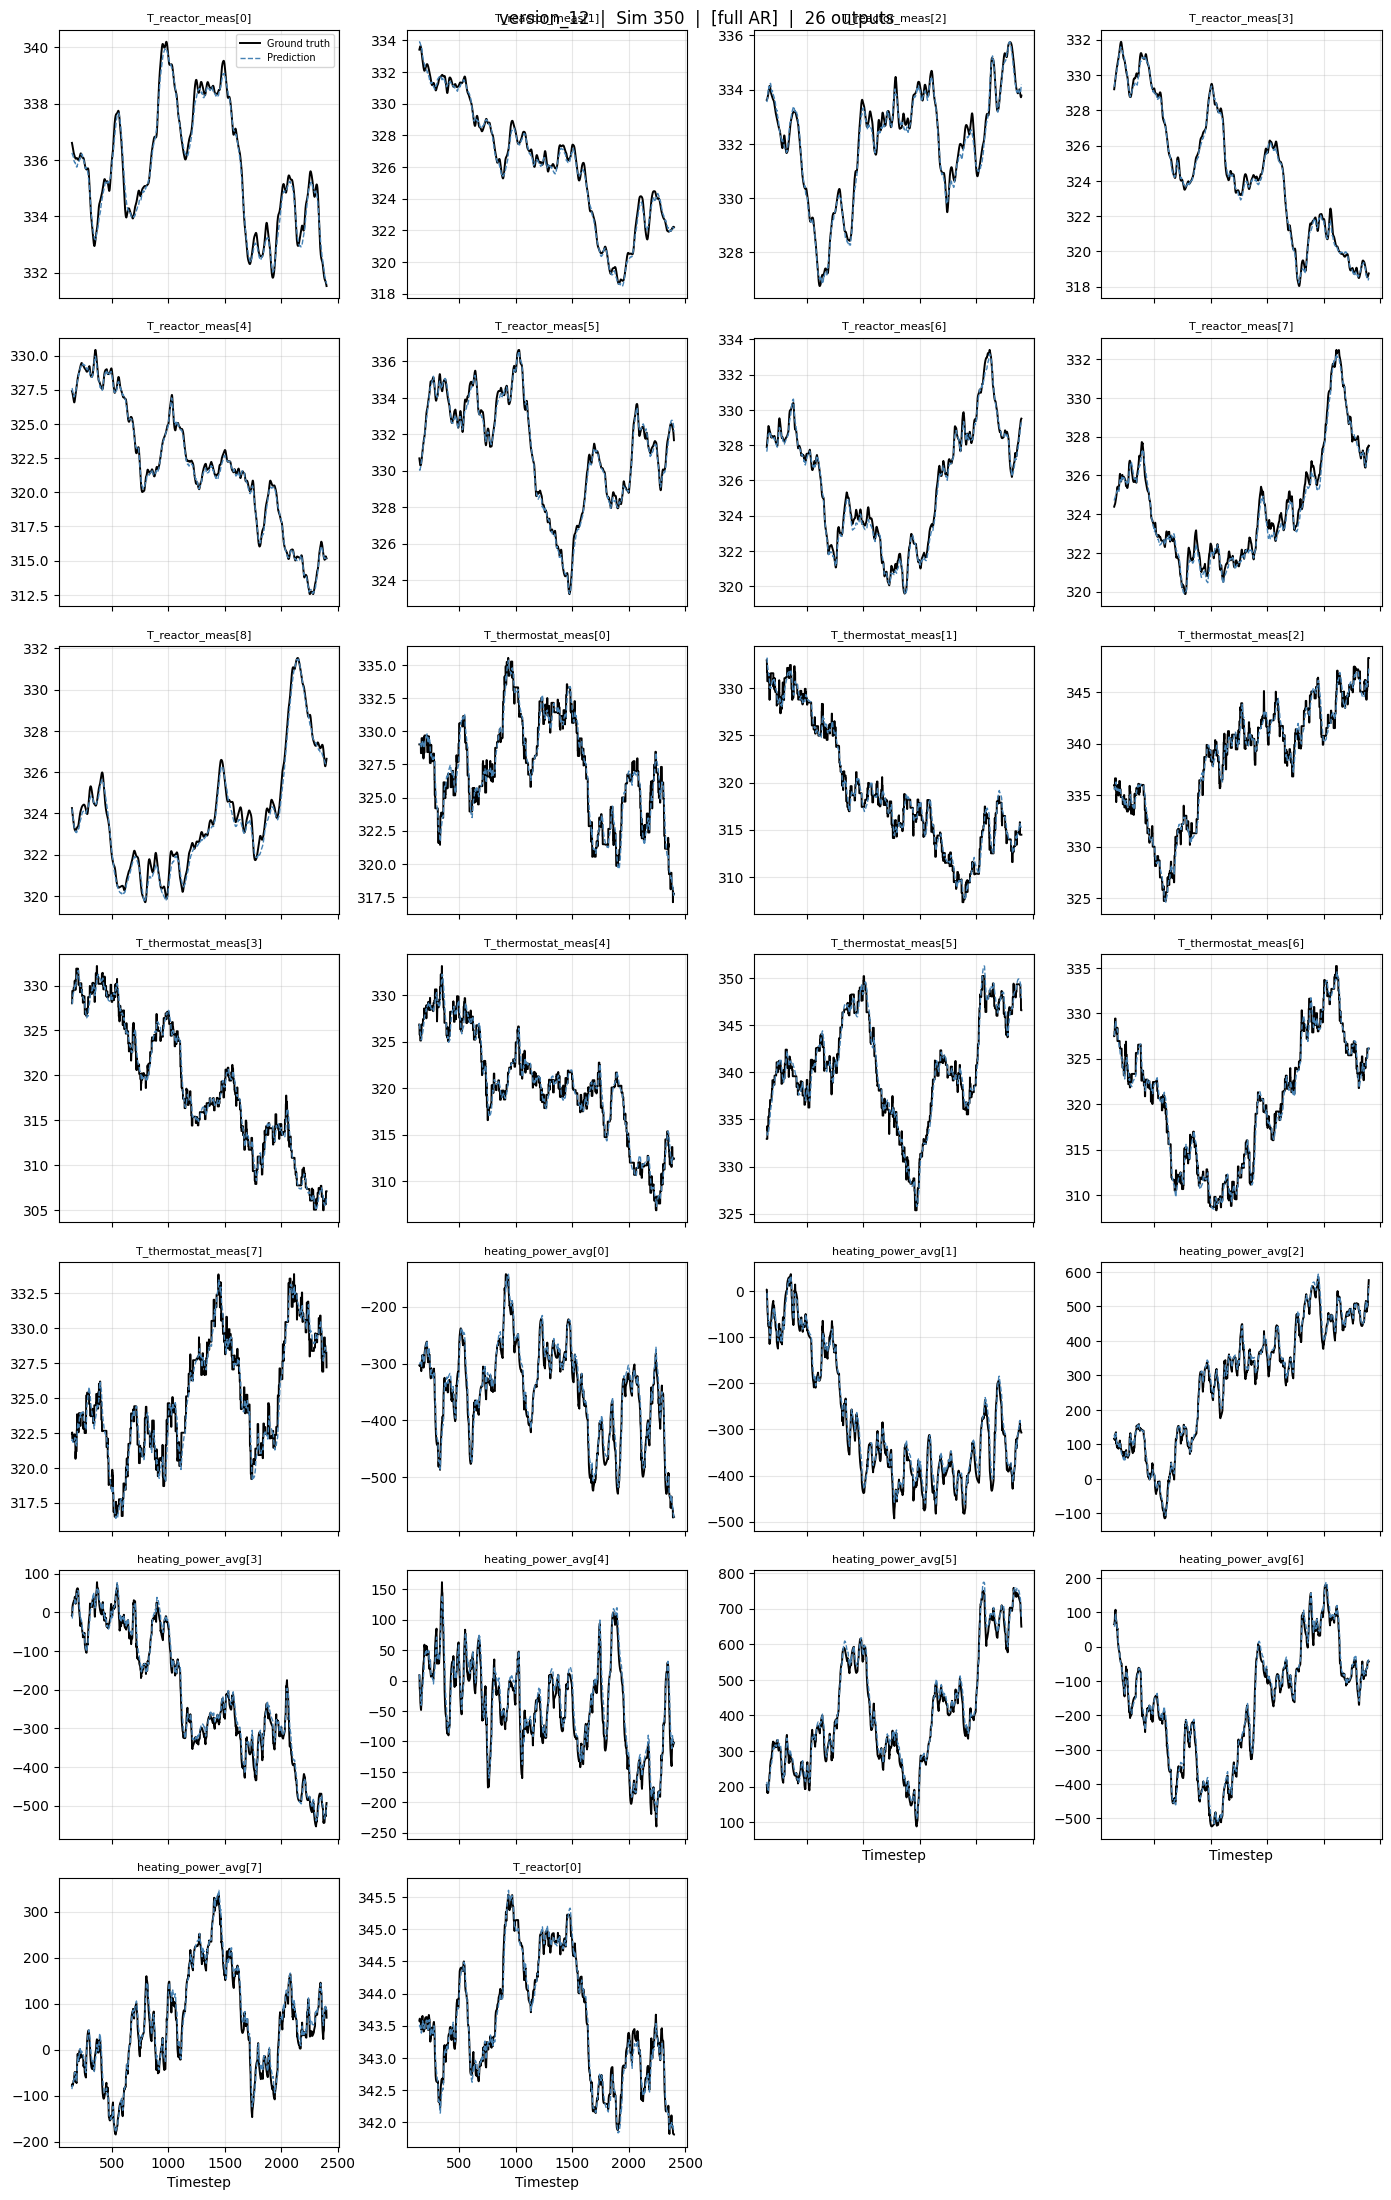

Saved: Models\version_12_full_AR_sim350.png


In [16]:
import h5py
import glob
import yaml

# ── CONFIG ─────────────────────────────────────────────────────────────────────
ROLLOUT_RAW_HDF5 = '../../Data_Sampling/datasets/21_05_2026/thermal_cobr_raw_data.h5'
SIM_NUMBER       = 350    # int → use that sim; None → pick randomly
SIM_SEED         = 125      # used only when SIM_NUMBER is None

MODELS_ROOT    = 'Models'
COMPARE_MODELS = ['version_12']   # list of versions to evaluate; None → all with narx_model_full.pt

# Partial AR: only T_reactor_meas + T_thermostat_meas fed back from predictions;
# heating_power_avg and integral_term slots always use ground truth.
# For new architecture models (v9+), heating_power_avg / integral_term are not in the
# feature window at all — _rollout_with_meta handles this automatically via metadata.
PARTIAL_AUTOREGRESSIVE = False
_PARTIAL_AR_VARS = {'T_reactor_meas', 'T_thermostat_meas'}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Resolve model dirs ─────────────────────────────────────────────────────────
if COMPARE_MODELS is None:
    _model_dirs = sorted(
        d for d in glob.glob(os.path.join(MODELS_ROOT, 'version_*'))
        if os.path.isfile(os.path.join(d, 'narx_model_full.pt'))
    )
else:
    _model_dirs = []
    for _v in COMPARE_MODELS:
        _d = os.path.join(MODELS_ROOT, _v)
        if not os.path.isfile(os.path.join(_d, 'narx_model_full.pt')):
            raise FileNotFoundError(f'No narx_model_full.pt in {_d}')
        _model_dirs.append(_d)

if not _model_dirs:
    raise RuntimeError(f'No models selected / found under {MODELS_ROOT}/')
print(f'Models to evaluate ({len(_model_dirs)}): {[os.path.basename(d) for d in _model_dirs]}')

# ── Pick simulation ────────────────────────────────────────────────────────────
with h5py.File(ROLLOUT_RAW_HDF5, 'r') as _f:
    _sim_ids = sorted(_f['simulations'].keys(), key=int)

_chosen = str(SIM_NUMBER if SIM_NUMBER is not None
              else np.random.default_rng(SIM_SEED).choice(_sim_ids))
if _chosen not in _sim_ids:
    raise ValueError(f'Sim {_chosen} not in {ROLLOUT_RAW_HDF5}')
print(f'Simulation : {_chosen}')


# ── Load all raw arrays from the chosen simulation ────────────────────────────
def _load_sim_raw(h5_path, sim_id):
    """Return dict {(group, varname): np.array(T, dims)} for all time-series in sim."""
    raw = {}
    with h5py.File(h5_path, 'r') as f:
        s = f[f'simulations/{sim_id}']
        for grp in ('aux', 'x', 'u', 'y'):
            if grp not in s:
                continue
            for k in s[grp]:
                a = np.array(s[grp][k])
                if a.ndim >= 1:
                    raw[(grp, k)] = a.reshape(a.shape[0], -1) if a.ndim > 1 else a.reshape(-1, 1)
    # Stack per-zone setpoints into (T, n_zones) if not already stored as a stacked array.
    if ('aux', 'T_setpoint_thermostats') not in raw:
        _cols = [raw[('u', f'T_setpoint_thermostat_{j}')]
                 for j in range(8)
                 if ('u', f'T_setpoint_thermostat_{j}') in raw]
        if _cols:
            raw[('aux', 'T_setpoint_thermostats')] = np.concatenate(_cols, axis=1)
    return raw

_raw = _load_sim_raw(ROLLOUT_RAW_HDF5, _chosen)
_T   = next(iter(_raw.values())).shape[0]
print(f'Sim length : {_T} steps')


# ── Helper: resolve column indices from a metadata entry ──────────────────────
def _idxs(entry):
    """Return a list of column indices for a metadata entry.

    YAML stores null when all columns are used; fall back to range(selected_dims).
    """
    v = entry.get('indices')
    return list(v) if v is not None else list(range(entry['selected_dims']))


# ── Rollout helpers ────────────────────────────────────────────────────────────

def _rollout_with_meta(model_dir, raw, T_sim, partial_ar, partial_ar_vars):
    """Metadata-driven rollout for models that have model_metadata.yml."""
    with open(os.path.join(model_dir, 'model_metadata.yml')) as _f:
        meta = yaml.safe_load(_f)

    m = torch.load(os.path.join(model_dir, 'narx_model_full.pt'),
                   map_location=DEVICE, weights_only=False)
    m.eval()

    fs    = load_scaler_params(os.path.join(model_dir, 'feature_scaler.yml'))
    ls    = load_scaler_params(os.path.join(model_dir, 'label_scaler.yml'))
    fmean = np.array(fs['mean']); fstd = np.array(fs['std'])
    lmean = np.array(ls['mean']); lstd = np.array(ls['std'])

    feat_entries  = meta['dataset_metadata']['feature_groups']['narx_state_features']
    label_entries = meta['dataset_metadata']['labels']
    lbl_names     = meta['model_config']['label_names']
    n_past        = meta['n_past']
    n_out         = len(lbl_names)

    # Ground-truth matrix (T, n_out)
    _y_parts = []
    for lbl in label_entries:
        _arr = raw[(lbl['type'], lbl['name'])]
        if lbl.get('reduce') == 'max':
            _y_parts.append(_arr.max(axis=1, keepdims=True))
        else:
            _y_parts.append(_arr[:, _idxs(lbl)])
    y_gt = np.concatenate(_y_parts, axis=1)

    # AR state buffers: {var_name: (n_past, dims)} — initialized from GT
    state_buf = {}
    for e in feat_entries:
        if e['narx_type'] != 'feature':
            continue
        state_buf[e['name']] = raw[(e['type'], e['name'])][:n_past, _idxs(e)].copy()

    # Label var → column slice in pred vector
    lbl_slices, off = {}, 0
    for lbl in label_entries:
        d = lbl['selected_dims']
        lbl_slices[lbl['name']] = slice(off, off + d)
        off += d

    ar_vars = partial_ar_vars if partial_ar else set(state_buf.keys())

    # Rollout: preds[i] = prediction for timestep n_past + i
    preds = np.zeros((T_sim - n_past, n_out))

    with torch.no_grad():
        for i, k in enumerate(range(n_past - 1, T_sim - 1)):
            parts = []
            for e in feat_entries:
                if e['narx_type'] == 'feature':
                    parts.append(state_buf[e['name']].flatten())
                else:
                    arr   = raw[(e['type'], e['name'])]
                    delay = e.get('delay', 0)
                    win_i = np.clip(
                        np.arange(k - e['n_past'] - delay + 1, k - delay + 1), 0, T_sim - 1
                    )
                    parts.append(arr[win_i][:, _idxs(e)].flatten())

            feat_sc  = (np.concatenate(parts) - fmean) / fstd
            pred_sc  = m.predict(torch.tensor(feat_sc, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                         ).squeeze(0).cpu().numpy()
            pred     = pred_sc * lstd + lmean
            preds[i] = pred

            k_next = min(k + 1, T_sim - 1)
            for e in feat_entries:
                if e['narx_type'] != 'feature':
                    continue
                name = e['name']
                buf  = np.roll(state_buf[name], -1, axis=0)
                if name in lbl_slices:
                    sl = lbl_slices[name]
                    buf[-1] = pred[sl] if name in ar_vars else y_gt[k_next, sl]
                else:
                    arr = raw[(e['type'], e['name'])]
                    buf[-1] = arr[k_next, _idxs(e)]
                state_buf[name] = buf

    return preds, y_gt, lbl_names, n_past


def _rollout_legacy(model_dir, raw, T_sim, partial_ar):
    """Fallback for version_6/7-style models (no metadata file).

    Assumes N_CTRL=5 (flow + 4 setpoints) and 4 equal-size output groups.
    """
    m = torch.load(os.path.join(model_dir, 'narx_model_full.pt'),
                   map_location=DEVICE, weights_only=False)
    m.eval()

    fs    = load_scaler_params(os.path.join(model_dir, 'feature_scaler.yml'))
    ls    = load_scaler_params(os.path.join(model_dir, 'label_scaler.yml'))
    fmean = np.array(fs['mean']); fstd = np.array(fs['std'])
    lmean = np.array(ls['mean']); lstd = np.array(ls['std'])

    n_out  = lmean.shape[0]
    N_CTRL = 5
    n_per  = n_out // 4
    N_PAST = fmean.shape[0] // (n_out + N_CTRL)

    _z = lambda: np.zeros((T_sim, n_per))
    reac  = raw.get(('aux', 'T_reactor_meas'),   _z())[:, :n_per]
    therm = raw.get(('aux', 'T_thermostat_meas'), _z())[:, :n_per]
    hp    = raw.get(('x',   'heating_power_avg'), _z())[:, :n_per]
    intg  = raw.get(('x',   'integral_term'),     _z())[:, :n_per]
    y_gt  = np.concatenate([reac, therm, hp, intg], axis=1)

    flow  = raw.get(('u', 'flow_inlet'), np.zeros((T_sim, 1)))
    tsps  = [raw.get(('u', f'T_setpoint_thermostat_{j}'), np.zeros((T_sim, 1))) for j in range(4)]
    u_all = np.concatenate([flow] + tsps, axis=1)

    preds  = np.zeros((T_sim - N_PAST, n_out))
    y_win  = y_gt[:N_PAST].copy()
    ar_end = n_per * 2   # T_reactor + T_thermostat columns

    with torch.no_grad():
        for i, k in enumerate(range(N_PAST - 1, T_sim - 1)):
            u_win   = u_all[np.clip(np.arange(k - N_PAST, k), 0, T_sim - 1)]
            feat    = np.concatenate(
                [y_win[:, v * n_per:(v + 1) * n_per].flatten() for v in range(4)] +
                [u_win[:, c] for c in range(N_CTRL)]
            )
            feat_sc = (feat - fmean) / fstd
            pred_sc = m(torch.tensor(feat_sc, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                        ).squeeze(0).cpu().numpy()
            pred    = pred_sc * lstd + lmean
            preds[i] = pred

            y_win = np.roll(y_win, -1, axis=0)
            k_next = min(k + 1, T_sim - 1)
            if partial_ar:
                y_win[-1, :ar_end] = pred[:ar_end]
                y_win[-1, ar_end:] = y_gt[k_next, ar_end:n_out]
            else:
                y_win[-1] = pred

    lbl_names = [f'{g}[{i}]'
                 for g in ['T_reactor_meas', 'T_thermostat_meas',
                            'heating_power_avg', 'integral_term']
                 for i in range(n_per)]
    return preds, y_gt, lbl_names[:n_out], N_PAST


# ── Run rollouts ───────────────────────────────────────────────────────────────
_results = {}

for _d in _model_dirs:
    _v       = os.path.basename(_d)
    _md_path = os.path.join(_d, 'model_metadata.yml')
    _path    = 'metadata' if os.path.exists(_md_path) else 'legacy'
    print(f'  {_v}  [{_path}]  ...', end=' ', flush=True)
    try:
        if os.path.exists(_md_path):
            _p, _gt, _ln, _np = _rollout_with_meta(
                _d, _raw, _T, PARTIAL_AUTOREGRESSIVE, _PARTIAL_AR_VARS
            )
        else:
            _p, _gt, _ln, _np = _rollout_legacy(_d, _raw, _T, PARTIAL_AUTOREGRESSIVE)
        _results[_v] = {'preds': _p, 'y_gt': _gt, 'label_names': _ln, 'n_past': _np}
        print(f'OK  (steps={_p.shape[0]}, outputs={_p.shape[1]})')
    except Exception as _e:
        import traceback as _tb
        print(f'ERROR: {_e}')
        _tb.print_exc()

if not _results:
    raise RuntimeError('All rollouts failed.')

# ── Plot — one figure per model, showing that model's own outputs vs GT ────────
_mode_lbl = 'partial AR' if PARTIAL_AUTOREGRESSIVE else 'full AR'
_n_cols   = 4

for _vname, _res in _results.items():
    _lbl_names = _res['label_names']
    _n_out     = len(_lbl_names)
    _n_rows    = (_n_out + _n_cols - 1) // _n_cols
    _k_s       = _res['n_past']     # preds[0] aligns with y_gt[n_past]
    _t_ax      = np.arange(_k_s, _T)

    _fig, _axes = plt.subplots(_n_rows, _n_cols,
                                figsize=(14, 3.2 * _n_rows), sharex=True)
    _axes = np.array(_axes).flatten()

    for _i, _name in enumerate(_lbl_names):
        _ax = _axes[_i]
        _ax.plot(_t_ax, _res['y_gt'][_k_s:, _i],
                 color='black', linewidth=1.4, label='Ground truth')
        _ax.plot(_t_ax, _res['preds'][:, _i],
                 color='steelblue', linewidth=1.0, linestyle='--', label='Prediction')
        _ax.set_title(_name, fontsize=8)
        _ax.grid(True, alpha=0.3)
        if _i == 0:
            _ax.legend(fontsize=7, loc='best')

    for _ax in _axes[_n_out:]:
        _ax.set_visible(False)
    for _ax in _axes[max(0, _n_out - _n_cols):_n_out]:
        _ax.set_xlabel('Timestep')

    _fig.suptitle(
        f'{_vname}  |  Sim {_chosen}  |  [{_mode_lbl}]  |  {_n_out} outputs',
        fontsize=12,
    )
    _fig.tight_layout()

    _save_path = os.path.join(
        MODELS_ROOT,
        f'{_vname}_{_mode_lbl.replace(" ", "_")}_sim{_chosen}.png',
    )
    _fig.savefig(_save_path, dpi=150)
    plt.show()
    print(f'Saved: {_save_path}')